# Event Contract Mispricing via Options-Implied Probabilities

Thin driver for the `kalshi_arb` package. All logic lives in the package;
this notebook only orchestrates and plots. Parameters/assumptions are
documented in `../ASSUMPTIONS.md` and centralized in `kalshi_arb/config.py`.

Pipeline: **io → cleaning → vol → pricing → density → signals → backtest → metrics** (+ `hedging`).

Strategy is the **risk-managed** variant (`MAX_LOTS_PER_BUCKET = 1`, no pyramiding).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # import kalshi_arb from repo root
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from kalshi_arb import pipeline, run, config
from kalshi_arb.extract import kalshi as kalshi_src
from kalshi_arb.transform import density, buckets
from kalshi_arb.strategy import signals, backtest, metrics, hedging
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 20)

## 1. Build the cleaned + priced option chain (steps 2–4)

In [2]:
chain = pipeline.build_chain(save=True)   # clean → smooth vols → BSM + control variate
kalshi = kalshi_src.load_kalshi()
chain[['quote','option_type','strike','forward','IV','LSQ_Vol','Mid','BSM']].head()

[clean] dropped 3282 rows on 18 quote date(s) whose only available expiry rolled to next year (e.g. 2022-12-19..2023-12-29)
[clean] dropped 3011 rows violating no-arbitrage price bounds (stale deep-ITM quotes: mid outside [intrinsic, upper])


[clean] 344720 -> 304488 rows | IV missing 3190 -> 3


[price] MAE=4.38  RMSE=7.54  n=304486


[save] C:\HDD\Stevens\Semester 8 Submissions\FE800\FE800 Final Submission\kalshi_stat_arb\artifacts\clean_chain.parquet


,quote,option_type,strike,forward,IV,LSQ_Vol,Mid,BSM
0,2022-01-03,c,2600.0,4771.570065,0.3760,0.375997,2188.50,2184.052313
1,2022-01-03,p,2700.0,4771.570065,0.3904,0.388255,38.45,41.378652
2,2022-01-03,c,2700.0,4771.570065,0.3668,0.366818,2093.45,2089.144910
3,2022-01-03,p,2800.0,4771.570065,0.3694,0.371385,43.15,43.895023
4,2022-01-03,c,2800.0,4771.570065,0.3579,0.357906,1998.95,1994.802147


## 2. Risk-neutral densities (step 5)
Breeden–Litzenberger (primary) vs GBM. The BL density is built on a wide strike
grid with flat-vol extrapolation and is **not** renormalized to 1.

BL density mass: 1.0  breach: 0.034


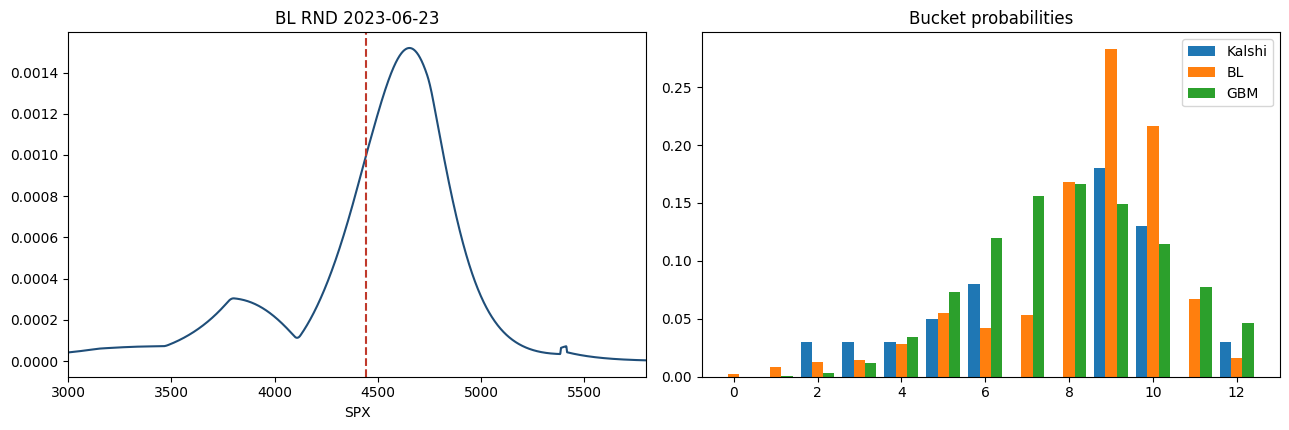

In [3]:
date = pd.Timestamp('2023-06-23'); day = chain[chain['quote']==date]
g, d = density.bl_density(day); F = day['forward'].iloc[0]
buckets = list(kalshi[2023]['price'].columns)
bl = density.bl_pmf(day, buckets); gb = density.gbm_pmf(day, buckets)
kp = kalshi[2023]['price'].reindex([date]).iloc[0] / 100
print('BL density mass:', round(np.trapz(d, g), 3), ' breach:', round(1-sum(bl.values()), 3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].plot(g, d, color='#1f4e79'); ax[0].axvline(F, color='#c0392b', ls='--')
ax[0].set_xlim(3000, 5800); ax[0].set_title(f'BL RND {date.date()}'); ax[0].set_xlabel('SPX')
x = np.arange(len(buckets)); w = 0.27
ax[1].bar(x-w, kp.values, w, label='Kalshi'); ax[1].bar(x, [bl[b] for b in buckets], w, label='BL')
ax[1].bar(x+w, [gb[b] for b in buckets], w, label='GBM'); ax[1].legend(); ax[1].set_title('Bucket probabilities')
plt.tight_layout(); plt.show()

## 3. Full backtest sweep (steps 6–8)
BL & GBM × {2022, 2023, 2024} × {both, buy-only, sell-only}. Metrics are
252-annualized consistently for strategy and benchmark; drawdown is on the
strategy; settlement uses the true year-end S&P 500 close.

In [4]:
table, results, pmf = run.full(chain=chain, kalshi=kalshi, verbose=False)
cols = ['year','model','side','ann_return','ann_vol','sharpe','max_dd',
        'alpha_daily','beta','model_rho','n_trades','settlement','final_value']
config.ARTIFACT_DIR.mkdir(exist_ok=True)
table[cols].to_csv(config.ARTIFACT_DIR / 'results_table.csv', index=False)
table[cols]

,year,model,side,ann_return,ann_vol,sharpe,max_dd,alpha_daily,beta,model_rho,n_trades,settlement,final_value
0,2022,BL,both,7.43,4.18,1.06,-1.60,0.02,0.002,0.17,48,8.0,222.63
1,2022,BL,buy,2.88,2.45,-0.05,-1.37,-0.00,-0.005,0.51,13,8.0,207.97
2,2022,BL,sell,2.70,2.50,-0.12,-1.79,-0.00,0.002,0.49,11,-8.0,208.23
3,2023,BL,both,4.97,3.12,0.63,-1.99,0.01,0.035,0.00,52,0.0,215.06
4,2023,BL,buy,3.43,2.58,0.17,-1.66,0.00,0.019,0.25,9,8.0,209.82
5,2023,BL,sell,3.22,1.97,0.11,-1.14,0.00,0.018,0.05,13,-8.0,209.86
6,2024,BL,both,3.68,5.74,0.12,-4.06,0.00,0.003,0.62,32,0.0,210.76
7,2024,BL,buy,1.06,5.78,-0.34,-4.42,-0.01,0.004,0.60,7,0.0,202.21
8,2024,BL,sell,4.00,5.80,0.17,-4.31,0.00,-0.004,0.64,9,0.0,211.90
9,2022,GBM,both,7.94,3.52,1.40,-2.03,0.02,0.002,0.07,47,8.0,224.14


## 4. Equity curves — BL 'both' vs SPX

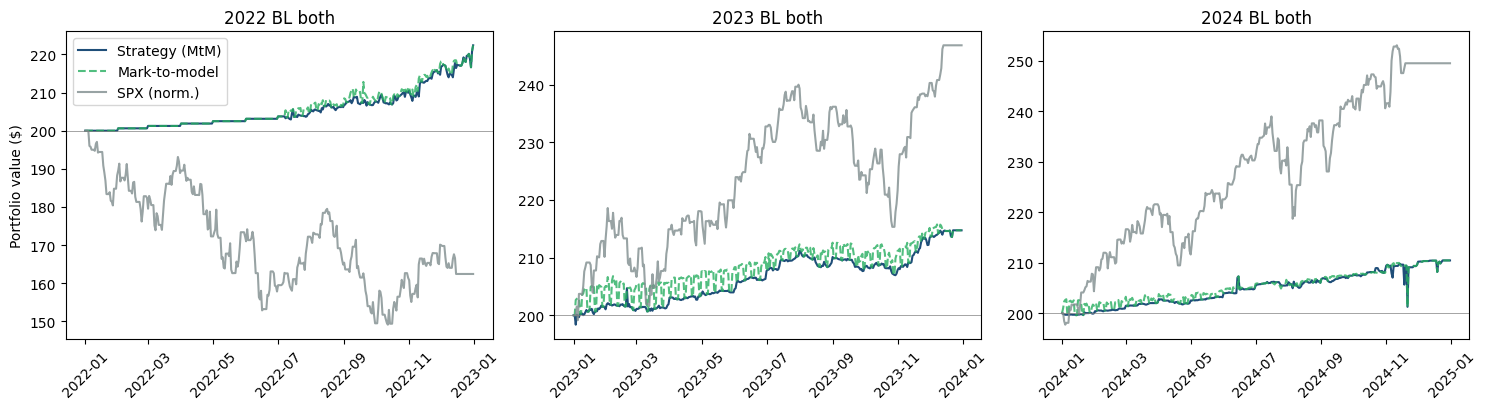

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for i, y in enumerate(config.YEARS):
    m = results[(y, 'bl', 'both')]
    spx = metrics.spx_benchmark(chain, y, m.index); spx = config.START_CASH * spx / spx.iloc[0]
    ax[i].plot(m.index, m['portfolio_value'], color='#1f4e79', label='Strategy (MtM)')
    ax[i].plot(m.index, m['model_value'], color='#27ae60', ls='--', alpha=0.8, label='Mark-to-model')
    ax[i].plot(spx.index, spx, color='#7f8c8d', alpha=0.8, label='SPX (norm.)')
    ax[i].axhline(config.START_CASH, color='grey', lw=0.5); ax[i].set_title(f'{y} BL both')
    ax[i].tick_params(axis='x', rotation=45)
    if i == 0: ax[i].legend(); ax[i].set_ylabel('Portfolio value ($)')
plt.tight_layout(); plt.savefig(config.ARTIFACT_DIR / 'equity_curves_bl.png', dpi=130, bbox_inches='tight'); plt.show()

## 5. Hedging — SPX iron-condor replication (cross-market check)
Static replication + basis-risk analysis. Full daily-MTM hedged backtest is
future work (see ASSUMPTIONS.md §7).

In [6]:
frames = [hedging.analyze_year(chain, kalshi, y) for y in config.YEARS]
for y, f in zip(config.YEARS, frames): f['year'] = y
allh = pd.concat(frames)
print('Share of quotes with >5c cross-market dislocation:', round((allh['edge'].abs() > 0.05).mean(), 3))
allh.groupby('year')[['edge','basis']].agg(['mean','std']).round(3)

[hedge 2022] 950 obs | mean |edge|=0.040 | mean basis=0.016 | corr(kalshi,condor)=0.80


[hedge 2023] 2302 obs | mean |edge|=0.044 | mean basis=0.033 | corr(kalshi,condor)=0.71


[hedge 2024] 1118 obs | mean |edge|=0.056 | mean basis=0.020 | corr(kalshi,condor)=0.26
Share of quotes with >5c cross-market dislocation: 0.241


edge         basis       
       mean    std   mean    std
year                            
2022  0.009  0.067  0.016  0.033
2023  0.011  0.093  0.033  0.043
2024  0.014  0.130  0.020  0.013